In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# FILTER TO DISCOUNT RECIPIENTS
print("\n🎯 FILTERING TO DISCOUNT RECIPIENTS")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

# Get customers with discount
has_discount = df_quotes.groupby('numero_compte')['mt_remise_exceptionnelle_ht'].apply(
    lambda x: (x < 0).any()  # Negative = discount
)

discount_recipient_ids = has_discount[has_discount].index.tolist()

# Filter data
df_quotes_discount = df_quotes[df_quotes['numero_compte'].isin(discount_recipient_ids)].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"Discount recipients: {len(discount_recipient_ids):,}")
print(f"Quotes: {len(df_quotes_discount):,}")

# Save to file
df_quotes_discount.to_csv('cleaned_quote_data_discount.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_discount.csv")


🎯 FILTERING TO DISCOUNT RECIPIENTS
Original customers: 23,888
Discount recipients: 7,487
Quotes: 11,851

✅ Saved to cleaned_quote_data_discount.csv


In [3]:
df_quotes = pd.read_csv('cleaned_quote_data_discount.csv')

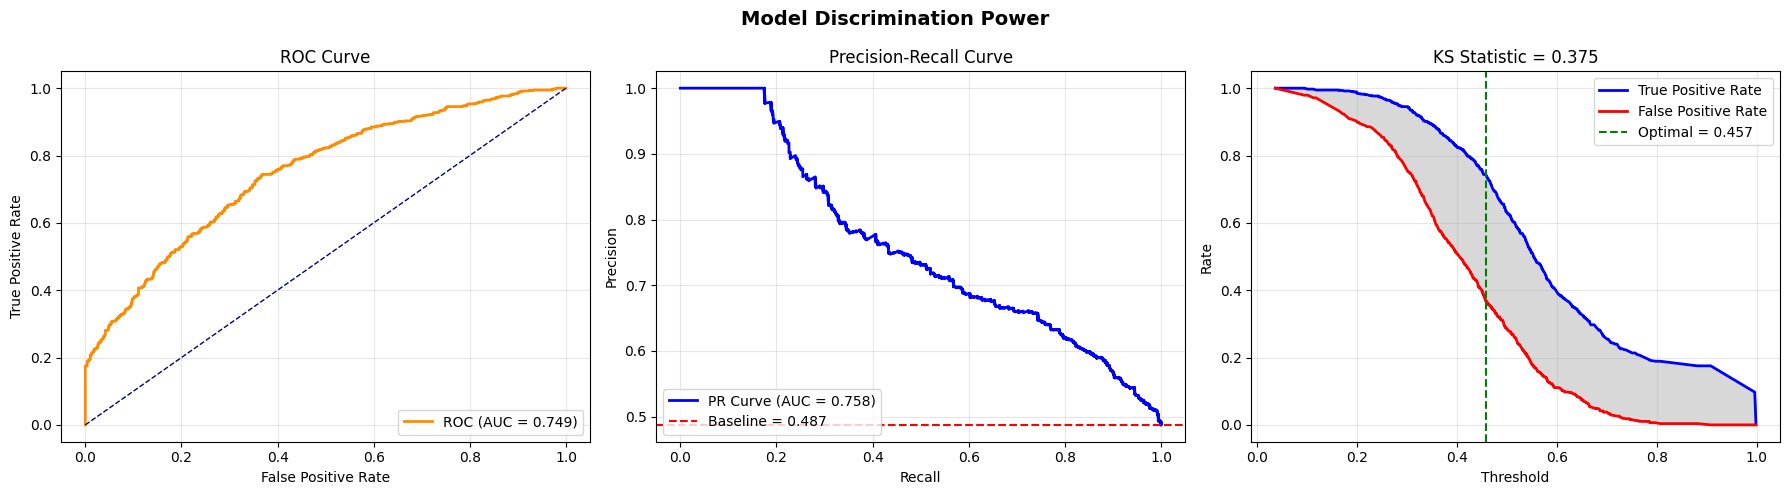

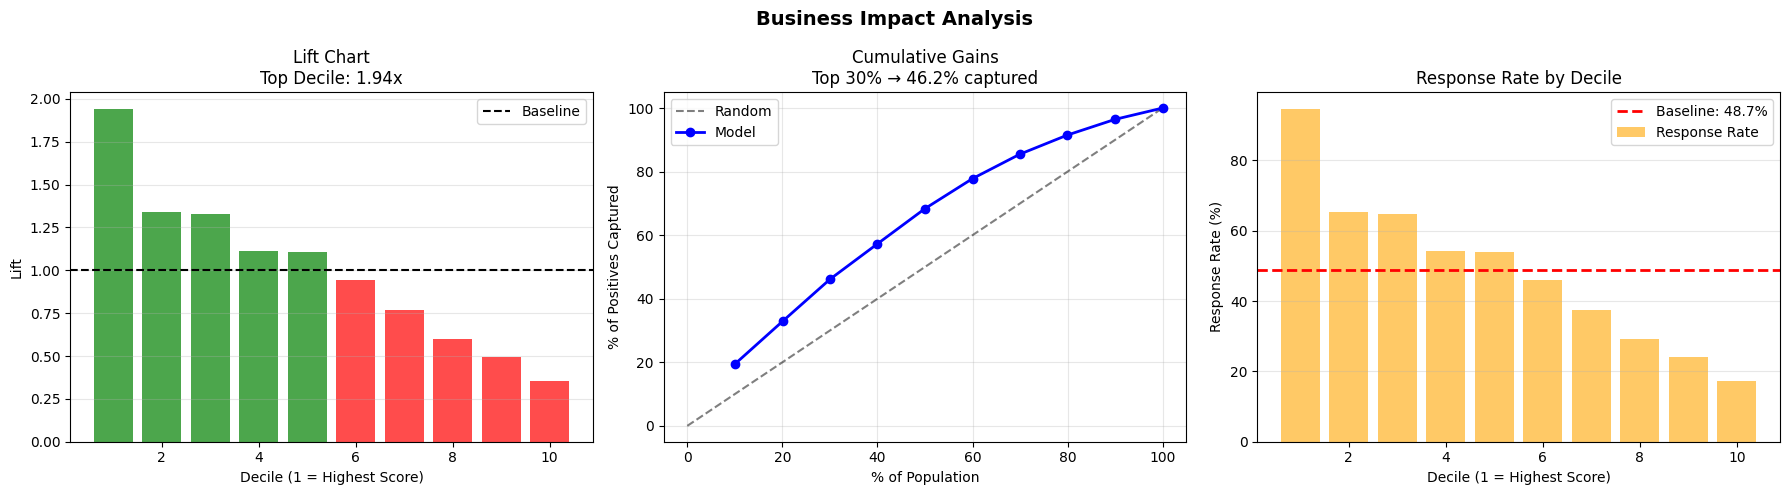

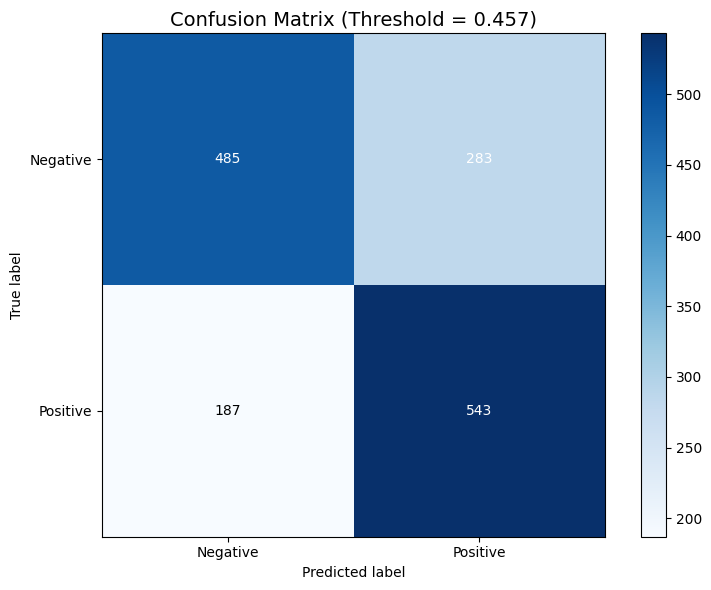


🔍 COMPREHENSIVE ERROR ANALYSIS
COMPREHENSIVE ERROR ANALYSIS

📊 1. BASIC ERROR METRICS
------------------------------------------------------------
Confusion Matrix:
  True Negatives:     549 (Correctly rejected)
  False Positives:    219 (Predicted YES, actual NO) ← WASTED EFFORT
  False Negatives:    270 (Predicted NO, actual YES) ← MISSED OPPORTUNITIES
  True Positives:     460 (Correctly predicted)

Error Analysis:
  • Total errors: 489 (32.6% of predictions)
  • False Positive rate: 14.6% (wasted sales effort)
  • False Negative rate: 18.0% (missed conversions)

📈 2. PREDICTION CONFIDENCE ANALYSIS
------------------------------------------------------------
Accuracy by Confidence Level:
  • Very Low   confidence: 82.4% accurate (227 predictions)
  • Low        confidence: 68.2% accurate (280 predictions)
  • Medium     confidence: 55.4% accurate (616 predictions)
  • High       confidence: 64.8% accurate (159 predictions)
  • Very High  confidence: 86.6% accurate (216 predictions)

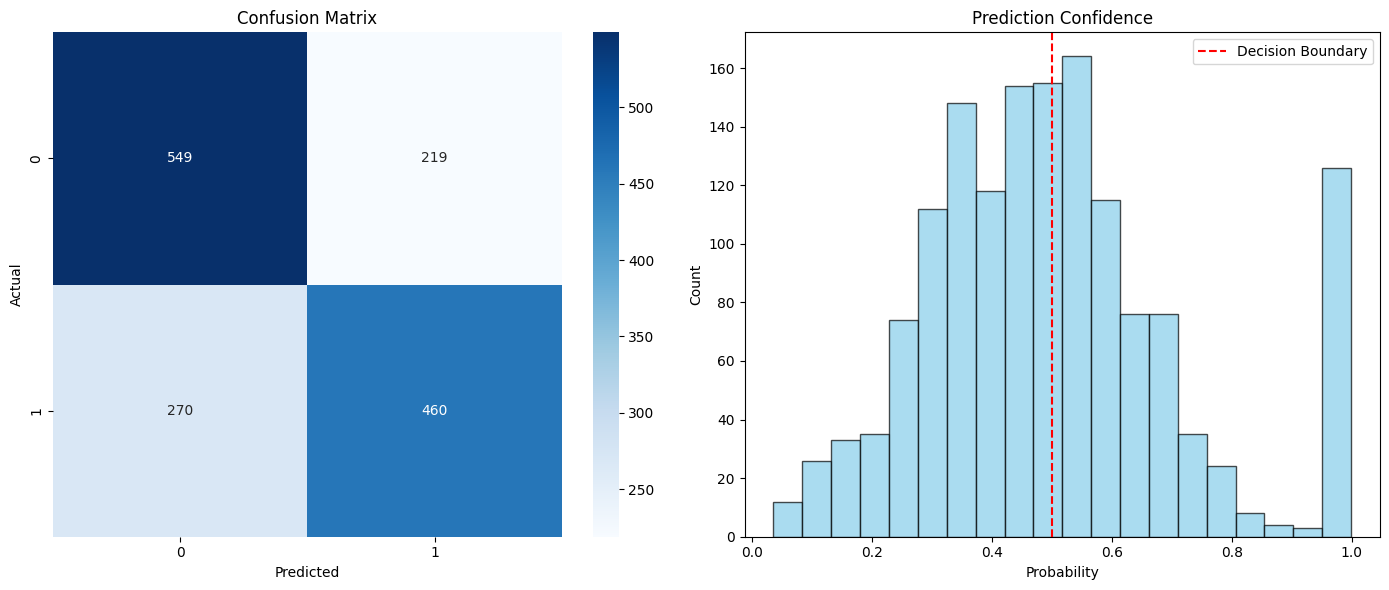

In [4]:
with redirect_stdout(open('/dev/null', 'w')):
    result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])